# Puzzle Solver – Ideen, Ansätze und Umsetzung

In diesem Projekt haben wir untersucht, wie man mithilfe von klassischer 2D-Computer-Vision einen Puzzle-Solver entwickeln kann – also.

Unser Ziel war es, eine Anwendung zu entwickeln, die visuell erkennt:
- welche Puzzleteile zusammengehören,
- oder wohin ein Teil im fertigen Puzzle gehört.


## Ideenphase: Was soll der Puzzle Solver können?

Wir haben zunächst verschiedene Anwendungsmöglichkeiten gesammelt:

1. 📷 **Zwei Puzzleteile fotografieren**  
   → Der Solver entscheidet, ob sie zusammengehören.

2. 🧩 **Viele Teile auf einmal fotografieren**  
   → Der Solver erkennt automatisch passende Puzzleteile.

3. 🖼️ **Einzelnes Teil + fertige Puzzle-Vorlage**  
   → Der Solver zeigt, wo das Teil im Gesamtbild hingehört.


## Umsetzungsideen 

Wir haben verschiedene Ansätze diskutiert:

### Idee 1: Formbasierte Kantenerkennung
- Annahme: Bei Erwachsenenpuzzles passen die Teile **nur durch die Form** zusammen.
- Ansatz: Kanten der Puzzleteile extrahieren und analysieren, ob zwei Kanten geometrisch zueinander passen (z. B. konvex ↔ konkav).

### Idee 2: Farbvergleich an den Rändern
- Idee: Vergleiche die **Farbverläufe entlang der Ränder** der Puzzleteile.
- Randbereiche extrahieren (z. B. als Streifen von 5–10 Pixeln) und RGB- oder HSV-Werte vergleichen.

### Idee 3: Lokalisierung durch Bildähnlichkeit
- Aufgabe: Ein einzelnes Puzzleteil soll in einem Bild des fertigen Puzzles lokalisiert werden.
- Lösung: Das Puzzleteil wird freigestellt und systematisch über das vollständige Bild geschoben.
- An jeder Position wird die Ähnlichkeit zwischen dem Teil und dem entsprechenden Ausschnitt des Gesamtbildes berechnet.
- Die Position mit der höchsten Übereinstimmung wird als wahrscheinliche Stelle für das Teil angenommen.


## Umsetzung von Idee 3: Teil im Gesamtbild finden

Als ersten Schritt für diese Variante mussten wir das einzelne Puzzleteil freistellen, um nur das Teil (ohne weißen Hintergrund) mit dem Gesamtbild vergleichen zu können.

Dazu haben wir eine einfache Punktoperation verwendet, die alle fast weißen Pixel (RGB-Werte über einem Schwellenwert) entfernt und durch Transparenz ersetzt.

So entsteht ein freigestelltes Puzzleteil mit Alpha-Kanal.


In [135]:
import numpy as np
import imageio.v3 as iio  # alternativ: matplotlib.image.imread

def remove_white_background(image_path: str, threshold: int = 240, save_path: str = None, crop: bool = True):
    """
    Entfernt weißen Hintergrund aus einem Bild und gibt ein RGBA-Bild zurück.
    Optional wird das Bild auf die sichtbare Inhaltsfläche zugeschnitten.

    :param image_path: Pfad zum Eingabebild.
    :param threshold: Schwellenwert für Weiß (Standard: 240).
    :param save_path: Optionaler Pfad zum Speichern des RGBA-Bildes.
    :param crop: Ob das Ergebnis auf den sichtbaren Bereich zugeschnitten werden soll.
    :return: RGBA-Bild als NumPy-Array.
    """
    # 1. Bild einlesen
    img = iio.imread(image_path)

    # 2. In uint8 wandeln, falls nötig
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)

    height, width, channels = img.shape

    # 3. Prüfen, ob Bild bereits einen Alpha-Kanal hat
    if channels == 4:
        rgb = img[..., :3]
    elif channels == 3:
        rgb = img
    else:
        raise ValueError(f"Unexpected number of channels: {channels}")

    # 4. Alpha-Kanal vorbereiten
    alpha = np.ones((height, width), dtype=np.uint8) * 255

    # 5. Transparenz berechnen
    white_mask = np.all(rgb >= threshold, axis=2)
    alpha[white_mask] = 0

    # 6. RGBA-Bild zusammenbauen
    rgba = np.zeros((height, width, 4), dtype=np.uint8)
    rgba[..., :3] = rgb
    rgba[..., 3] = alpha

    # 7. Zuschneiden, falls aktiviert
    if crop:
        nonzero = np.argwhere(alpha > 0)
        if nonzero.size > 0:
            y_min, x_min = nonzero.min(axis=0)
            y_max, x_max = nonzero.max(axis=0) + 1
            rgba = rgba[y_min:y_max, x_min:x_max]

    # 8. Optional speichern
    if save_path:
        iio.imwrite(save_path, rgba)

    return rgba


## Bildskalierung: Vorbereitung für den Rastervergleich

Um das Puzzleteil sinnvoll mit dem Gesamtpuzzle vergleichen zu können, müssen beide Bilder in **kompatiblen Größen** vorliegen.

Dazu haben wir zwei Funktionen entwickelt:

### 🔧 `resize_numpy_rgba_image`

Diese Funktion skaliert ein beliebiges RGBA-Bild auf eine gewünschte Breite (in Pixeln).  
Im Gegensatz zur ersten Version verwenden wir nun **OpenCV**, um effizienter und qualitativ hochwertiger zu interpolieren.

Die Funktionsweise:
- Die RGB-Kanäle werden mit **bilinearer Interpolation** (`INTER_LINEAR`) skaliert – das sorgt für weichere Übergänge.
- Der Alpha-Kanal wird mit **Nearest-Neighbor** (`INTER_NEAREST`) skaliert, um harte Transparenzgrenzen beizubehalten.
- Das Seitenverhältnis bleibt erhalten.

### 🧩 `resize_piece_to_fit_grid`

Diese Funktion sorgt dafür, dass das Puzzleteil genau die **Größe eines Rasterfelds** im Gesamtpuzzle bekommt. Das ist nötig, um das Teil später zellenweise vergleichen zu können.

Vorgehen:
1. Das Gesamtpuzzle wird auf eine einheitliche Zielbreite skaliert (z. B. 300 px).
2. Daraus wird berechnet, wie groß ein einzelnes Feld bei gegebener Spalten-/Zeilenzahl ist (z. B. bei 6 × 4).
3. Das Puzzleteil wird zunächst auf die passende Breite skaliert und ggf. in der Höhe noch einmal angepasst.
4. Auch hier wird OpenCV verwendet – für saubere und effiziente Skalierung.

Diese Vorbereitung ist entscheidend, um im nächsten Schritt das Puzzleteil über alle Felder des Gesamtbilds schieben und vergleichen zu können.


In [136]:
import numpy as np
import cv2

def resize_numpy_rgba_image(img: np.ndarray, new_width: int) -> np.ndarray:
    orig_h, orig_w = img.shape[:2]
    scale = new_width / orig_w
    new_h = int(orig_h * scale)

    # Bild und Alpha-Kanal separat behandeln
    rgb = img[..., :3]
    alpha = img[..., 3]

    resized_rgb = cv2.resize(rgb, (new_width, new_h), interpolation=cv2.INTER_LINEAR)
    resized_alpha = cv2.resize(alpha, (new_width, new_h), interpolation=cv2.INTER_NEAREST)

    # Wieder zusammensetzen
    resized = np.dstack((resized_rgb, resized_alpha))

    return resized


def resize_piece_to_fit_grid(piece_img: np.ndarray,
                             full_img: np.ndarray,
                             cols: int,
                             rows: int,
                             full_target_width: int) -> np.ndarray:
    # Puzzlebild skalieren
    resized_full = resize_numpy_rgba_image(full_img, new_width=full_target_width)
    resized_height = resized_full.shape[0]

    # Zielgröße eines Felds berechnen
    piece_target_width = full_target_width // cols
    piece_target_height = resized_height // rows

    # Einzelteil zuerst auf Breite skalieren
    piece_scaled = resize_numpy_rgba_image(piece_img, new_width=piece_target_width)

    # Falls Höhe nicht exakt passt → nochmal skalieren
    current_height = piece_scaled.shape[0]
    if current_height != piece_target_height:
        rgb = piece_scaled[..., :3]
        alpha = piece_scaled[..., 3]

        resized_rgb = cv2.resize(rgb, (piece_target_width, piece_target_height), interpolation=cv2.INTER_LINEAR)
        resized_alpha = cv2.resize(alpha, (piece_target_width, piece_target_height), interpolation=cv2.INTER_NEAREST)

        final_piece = np.dstack((resized_rgb, resized_alpha))
        return final_piece

    return piece_scaled


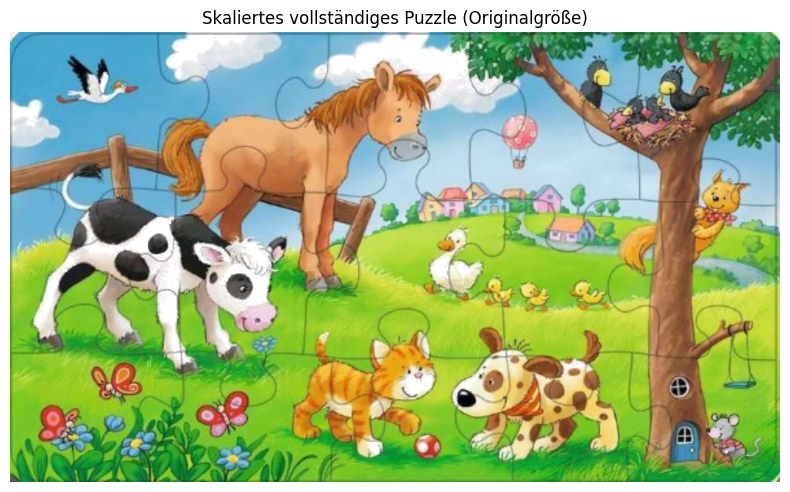

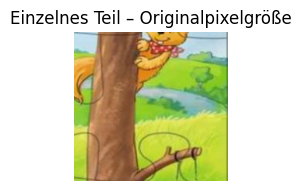

In [137]:
from matplotlib import pyplot as plt


puzzle_cols = 5
puzzle_rows = 3
target_full_width = 1000

# Lade vollständiges Puzzlebild
img_full = remove_white_background("fullkinderpuzzle.jpg")
resized_puzzle = resize_numpy_rgba_image(img_full, new_width=target_full_width)

# Lade einzelnes Teil
img_piece = remove_white_background("piece2.jpg", threshold=240)

# Skaliere Einzelteil passend zum Puzzle-Raster
resized_piece = resize_piece_to_fit_grid(
    piece_img=img_piece,
    full_img=img_full,
    cols=puzzle_cols,
    rows=puzzle_rows,
    full_target_width=target_full_width
)

# Anzeige – vollständiges Puzzle in Originalpixelgröße
h_puzzle, w_puzzle = resized_puzzle.shape[:2]
plt.figure(figsize=(w_puzzle / 100, h_puzzle / 100), dpi=100)
plt.imshow(resized_puzzle)
plt.title("Skaliertes vollständiges Puzzle (Originalgröße)")
plt.axis("off")

# Anzeige – einzelnes Teil in Originalpixelgröße
h_piece, w_piece = resized_piece.shape[:2]
plt.figure(figsize=(w_piece / 100, h_piece / 100), dpi=100)
plt.imshow(resized_piece)
plt.title("Einzelnes Teil – Originalpixelgröße")
plt.axis("off")

plt.show()


## Template Matching mit manueller MSE-Berechnung und Raster-Positionsvergleich

Im nächsten Schritt wollten wir herausfinden, **wo genau das freigestellte Puzzleteil im Gesamtbild vorkommt** – unabhängig von dessen Orientierung.

Dazu haben wir ein eigenes Template-Matching-Verfahren implementiert, das mit einer manuellen MSE-Berechnung (Mean Squared Error) arbeitet – ohne auf OpenCVs Standardfunktionen zurückzugreifen.

### Vorgehensweise:

1. 🔄 **Drehungen des Puzzleteils:**  
   Das Puzzleteil wird in vier Orientierungen getestet: 0°, 90°, 180°, 270°.  
   Bei jeder Drehung extrahieren wir nur den sichtbaren (nicht transparenten) Bereich, um den Vergleich auf reale Bildinhalte zu beschränken.

2. 🎯 **Rasterbasierter Vergleich mit dem Gesamtbild:**  
   Anstatt das Teil Pixel für Pixel zu verschieben, wird es **blockweise** über das Bild gelegt – jeweils um genau ein Feld weiter.  
   Dadurch wird jede mögliche Rasterposition (wie bei echten Puzzlefeldern) getestet.  
   An jeder Position vergleichen wir das Puzzleteil mit dem passenden Bildausschnitt und berechnen den **MSE**, also die durchschnittliche quadratische Abweichung der Farbwerte (RGB), nur in den sichtbaren Bereichen (Maske).

3. 🔥 **Heatmap-Visualisierung:**  
   Für jede Rotation wird eine Heatmap erzeugt, in der jede Rasterzelle den MSE-Wert für diese Position zeigt.  
   Je dunkler der Wert, desto besser passt das Teil an diese Stelle.

4. ✅ **Beste Übereinstimmung markieren:**  
   Die Position mit dem niedrigsten MSE-Wert wird als beste Übereinstimmung angenommen.  
   Diese wird im Originalbild mit einem grünen Rahmen markiert.  
   Dabei wird die Rasterposition korrekt in Bildkoordinaten zurückgerechnet (durch Multiplikation mit der Feldgröße).


## Farbenfroh

C:\Users\STI\AppData\Local\Temp\ipykernel_31172\1504562019.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


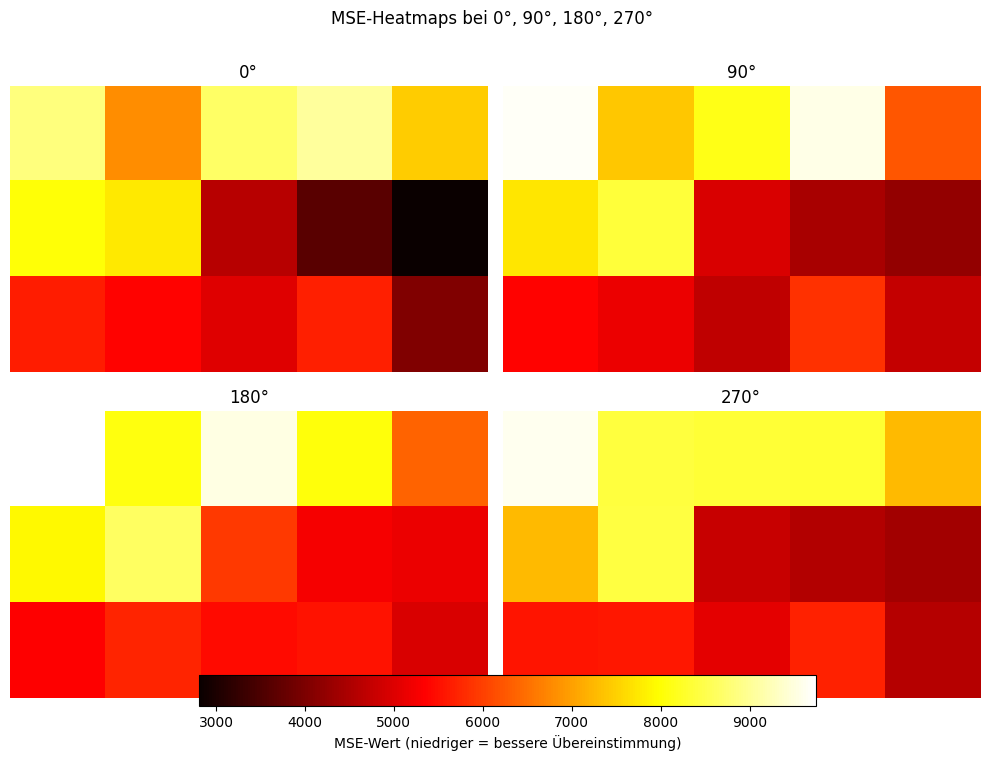

Beste Übereinstimmung:
  Score: 2814.7917
  Winkel: 0°
  Position: (x=800, y=194)
  Größe: 200x194


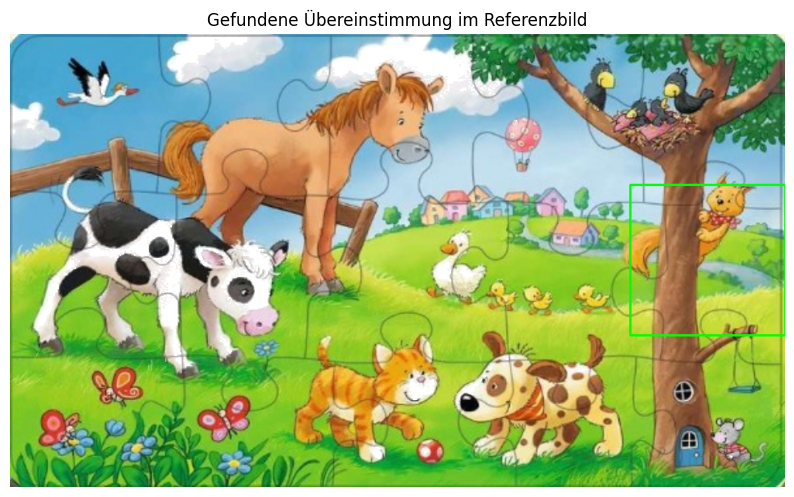

(np.float64(-0.5), np.float64(199.5), np.float64(193.5), np.float64(-0.5))

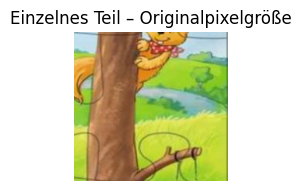

In [138]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


def extract_valid_template_region(template_rgba: np.ndarray, angle: int) -> tuple:
    h, w = template_rgba.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    rotated = cv2.warpAffine(template_rgba, M, (w, h),
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_CONSTANT,
                             borderValue=(0, 0, 0, 0))
    alpha = rotated[..., 3]
    nonzero = np.argwhere(alpha > 0)
    if nonzero.size == 0:
        return None, None
    y_min, x_min = nonzero.min(axis=0)
    y_max, x_max = nonzero.max(axis=0) + 1
    tpl_crop = rotated[y_min:y_max, x_min:x_max]
    mask = (tpl_crop[..., 3] > 0).astype(np.uint8)
    return tpl_crop, mask


def manual_template_matching_mse(image: np.ndarray, template: np.ndarray, mask: np.ndarray = None):
    
    img_h, img_w, _ = image.shape
    tpl_h, tpl_w, _ = template.shape

    # Schritte in y- und x-Richtung auf Stückgröße setzen
    step_y = tpl_h
    step_x = tpl_w

    res_h = (img_h - tpl_h) // step_y + 1
    res_w = (img_w - tpl_w) // step_x + 1
    result = np.full((res_h, res_w), fill_value=np.inf)

    for i_y, y in enumerate(range(0, img_h - tpl_h + 1, step_y)):
        for i_x, x in enumerate(range(0, img_w - tpl_w + 1, step_x)):
            patch = image[y:y + tpl_h, x:x + tpl_w, :3]
            tpl_rgb = template[..., :3]
            patch = patch.astype(np.float32)
            tpl_rgb = tpl_rgb.astype(np.float32)
            if mask is not None:
                mask_3d = np.repeat(mask[:, :, np.newaxis], 3, axis=2)
                diff = (patch - tpl_rgb)[mask_3d.astype(bool)]
            else:
                diff = (patch - tpl_rgb).ravel()
            if diff.size > 0:
                mse = np.mean(diff ** 2)
                result[i_y, i_x] = mse
    return result



def show_manual_mse_heatmap_with_rotations_and_best_match(img_rgba: np.ndarray,
                                                          tpl_rgba: np.ndarray):
    angles = (0, 90, 180, 270)
    heatmaps = []
    best_score = np.inf
    best_pos = (0, 0)
    best_angle = 0
    best_tpl = None

    for angle in angles:
        tpl_crop, mask = extract_valid_template_region(tpl_rgba, angle)
        if tpl_crop is None:
            heatmaps.append(np.zeros((1, 1)))
            continue
        res = manual_template_matching_mse(img_rgba, tpl_crop, mask)
        heatmaps.append(res)

        min_val = res.min()
        min_loc = np.unravel_index(np.argmin(res), res.shape)

        if min_val < best_score:
            best_score = min_val
            best_pos = min_loc
            best_angle = angle
            best_tpl = tpl_crop

    # Heatmap anzeigen
    all_min = min(hm.min() for hm in heatmaps)
    all_max = max(hm.max() for hm in heatmaps)

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs.ravel()

    for i, angle in enumerate(angles):
        hm = heatmaps[i]
        ax = axs[i]
        heat = ax.imshow(hm, cmap="hot", vmin=all_min, vmax=all_max, interpolation="nearest")
        ax.set_title(f"{angle}°")
        ax.axis("off")

    cbar = fig.colorbar(heat, ax=axs, orientation="horizontal", fraction=0.05, pad=0.08)
    cbar.set_label("MSE-Wert (niedriger = bessere Übereinstimmung)")

    fig.suptitle("MSE-Heatmaps bei 0°, 90°, 180°, 270° ")
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, bottom=0.12)
    plt.show()

    # Rechteck in Originalbild einzeichnen
    i_y, i_x = best_pos
    h, w = best_tpl.shape[:2]
    step_y = h 
    step_x = w 
    y0 = i_y * step_y
    x0 = i_x * step_x
    y1 = y0 + h
    x1 = x0 + w

    img_marked = img_rgba.copy()
    cv2.rectangle(img_marked, (x0, y0), (x1, y1), color=(0, 255, 0, 255), thickness=2)

    print(f"Beste Übereinstimmung:")
    print(f"  Score: {best_score:.4f}")
    print(f"  Winkel: {best_angle}°")
    print(f"  Position: (x={x0}, y={y0})")
    print(f"  Größe: {w}x{h}")

    return img_marked
matched_result = show_manual_mse_heatmap_with_rotations_and_best_match(resized_puzzle, resized_piece)

plt.figure(figsize=(10, 6))
plt.imshow(matched_result)
plt.title("Gefundene Übereinstimmung im Referenzbild")
plt.axis("off")
plt.show()
h_piece, w_piece = resized_piece.shape[:2]
plt.figure(figsize=(w_piece / 100, h_piece / 100), dpi=100)
plt.imshow(resized_piece)
plt.title("Einzelnes Teil – Originalpixelgröße")
plt.axis("off")

## Pyramid

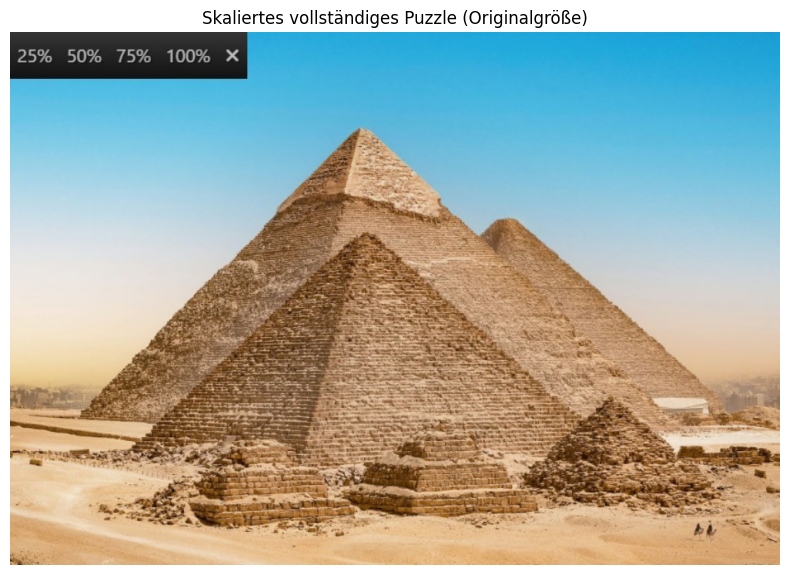

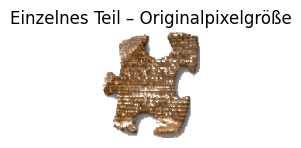

C:\Users\STI\AppData\Local\Temp\ipykernel_31172\1504562019.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


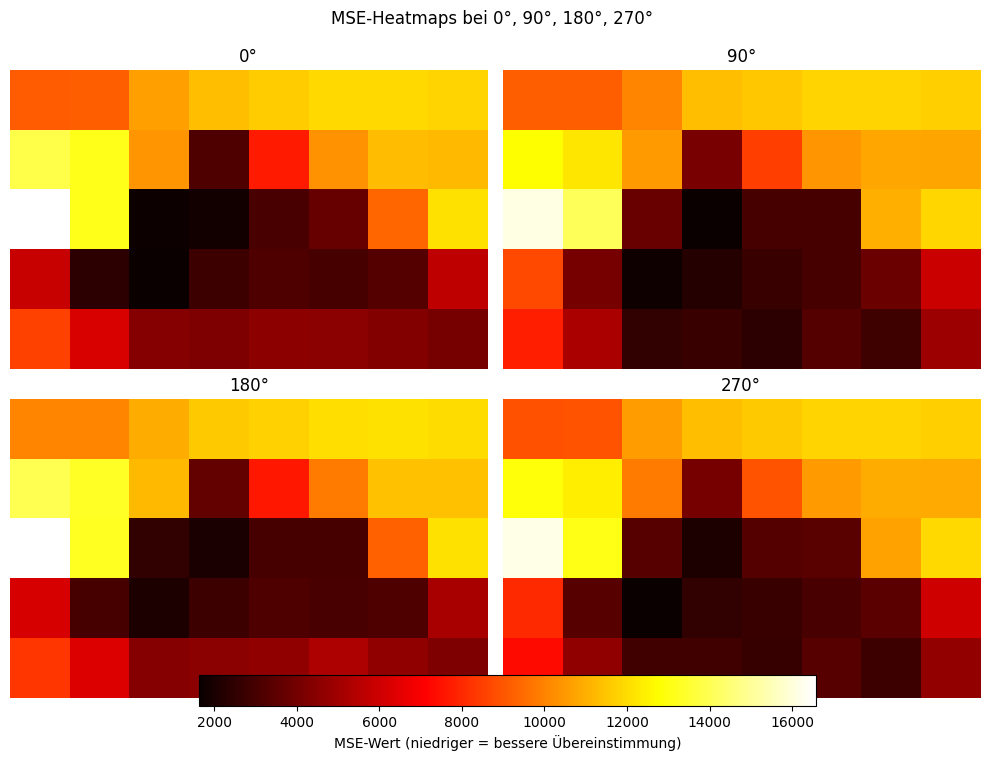

Beste Übereinstimmung:
  Score: 1646.0402
  Winkel: 0°
  Position: (x=250, y=414)
  Größe: 125x138


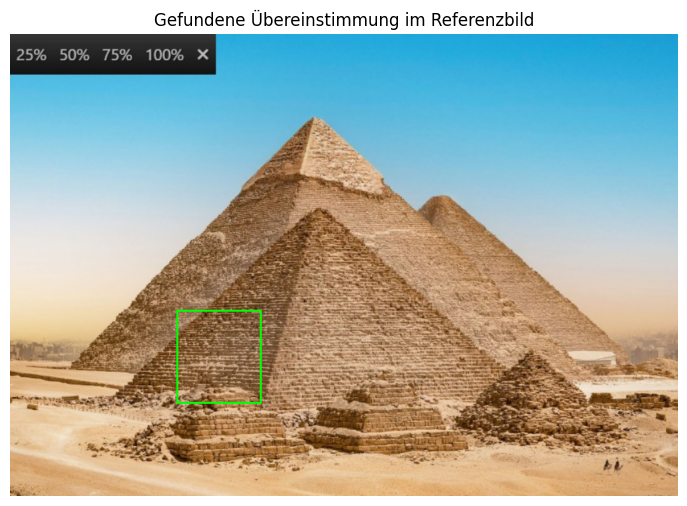

(np.float64(-0.5), np.float64(124.5), np.float64(137.5), np.float64(-0.5))

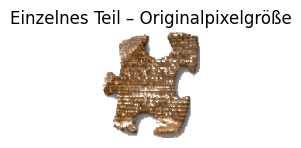

In [139]:

puzzle_cols = 8
puzzle_rows = 5
target_full_width = 1000

# Lade vollständiges Puzzlebild
img_full = remove_white_background("fullpyramid.jpg")
resized_puzzle = resize_numpy_rgba_image(img_full, new_width=target_full_width)

# Lade einzelnes Teil
img_piece = remove_white_background("pyramid1.jpg", threshold=140)

# Skaliere Einzelteil passend zum Puzzle-Raster
resized_piece = resize_piece_to_fit_grid(
    piece_img=img_piece,
    full_img=img_full,
    cols=puzzle_cols,
    rows=puzzle_rows,
    full_target_width=target_full_width
)

# Anzeige – vollständiges Puzzle in Originalpixelgröße
h_puzzle, w_puzzle = resized_puzzle.shape[:2]
plt.figure(figsize=(w_puzzle / 100, h_puzzle / 100), dpi=100)
plt.imshow(resized_puzzle)
plt.title("Skaliertes vollständiges Puzzle (Originalgröße)")
plt.axis("off")

# Anzeige – einzelnes Teil in Originalpixelgröße
h_piece, w_piece = resized_piece.shape[:2]
plt.figure(figsize=(w_piece / 100, h_piece / 100), dpi=100)
plt.imshow(resized_piece)
plt.title("Einzelnes Teil – Originalpixelgröße")
plt.axis("off")

plt.show()
matched_result = show_manual_mse_heatmap_with_rotations_and_best_match(resized_puzzle, resized_piece)

plt.figure(figsize=(10, 6))
plt.imshow(matched_result)
plt.title("Gefundene Übereinstimmung im Referenzbild")
plt.axis("off")
plt.show()
plt.figure(figsize=(w_piece / 100, h_piece / 100), dpi=100)
plt.imshow(resized_piece)
plt.title("Einzelnes Teil – Originalpixelgröße")
plt.axis("off")


## Wonka


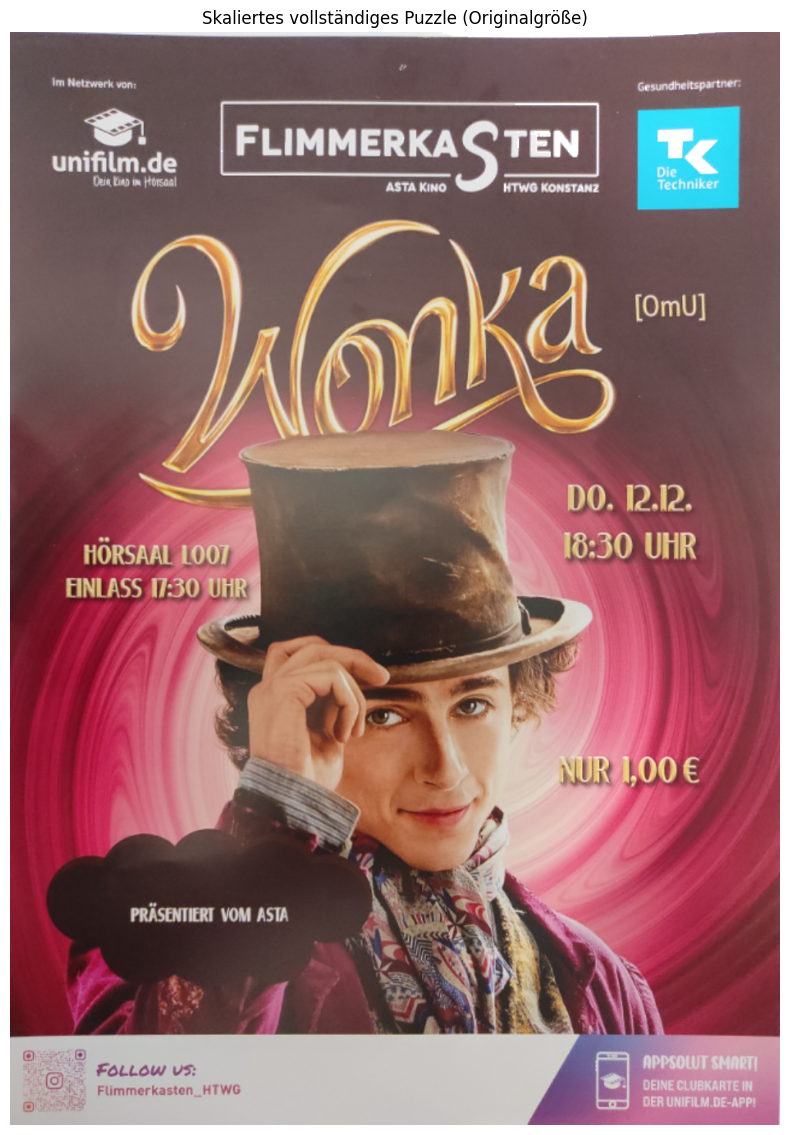

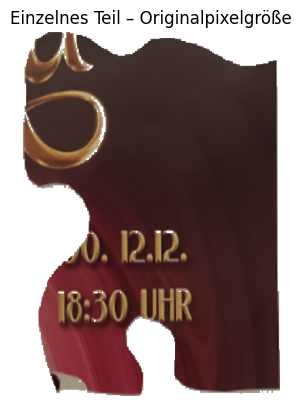

C:\Users\STI\AppData\Local\Temp\ipykernel_31172\1504562019.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


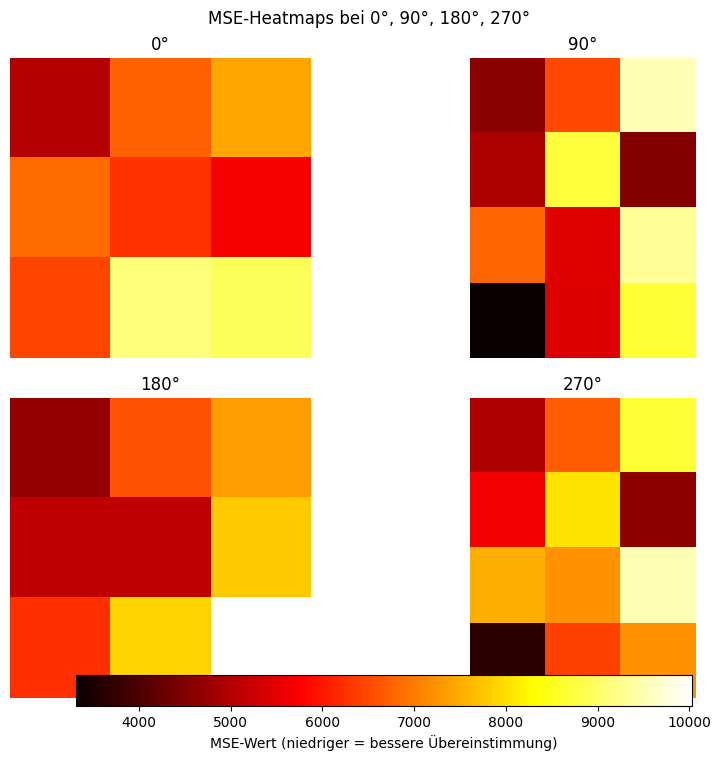

Beste Übereinstimmung:
  Score: 3314.5818
  Winkel: 90°
  Position: (x=0, y=996)
  Größe: 333x332


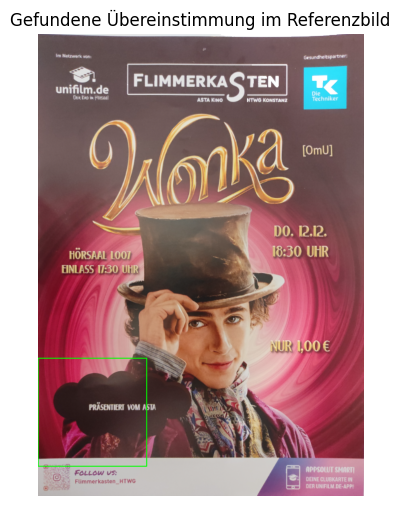

(np.float64(-0.5), np.float64(332.5), np.float64(472.5), np.float64(-0.5))

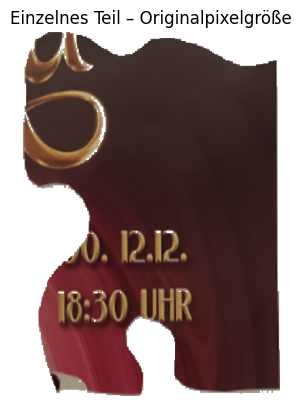

In [141]:

puzzle_cols = 3
puzzle_rows = 3
target_full_width = 1000

# Lade vollständiges Puzzlebild
img_full = remove_white_background("data/poster_puzzle_edited/wonka_full_edited.png")
resized_puzzle = resize_numpy_rgba_image(img_full, new_width=target_full_width)

# Lade einzelnes Teil
img_piece = remove_white_background("data/poster_puzzle_edited/wonka_002_edited.png", threshold=140)

# Skaliere Einzelteil passend zum Puzzle-Raster
resized_piece = resize_piece_to_fit_grid(
    piece_img=img_piece,
    full_img=img_full,
    cols=puzzle_cols,
    rows=puzzle_rows,
    full_target_width=target_full_width
)

# Anzeige – vollständiges Puzzle in Originalpixelgröße
h_puzzle, w_puzzle = resized_puzzle.shape[:2]
plt.figure(figsize=(w_puzzle / 100, h_puzzle / 100), dpi=100)
plt.imshow(resized_puzzle)
plt.title("Skaliertes vollständiges Puzzle (Originalgröße)")
plt.axis("off")

# Anzeige – einzelnes Teil in Originalpixelgröße
h_piece, w_piece = resized_piece.shape[:2]
plt.figure(figsize=(w_piece / 100, h_piece / 100), dpi=100)
plt.imshow(resized_piece)
plt.title("Einzelnes Teil – Originalpixelgröße")
plt.axis("off")

plt.show()
matched_result = show_manual_mse_heatmap_with_rotations_and_best_match(resized_puzzle, resized_piece)

plt.figure(figsize=(10, 6))
plt.imshow(matched_result)
plt.title("Gefundene Übereinstimmung im Referenzbild")
plt.axis("off")
plt.show()
plt.figure(figsize=(w_piece / 100, h_piece / 100), dpi=100)
plt.imshow(resized_piece)
plt.title("Einzelnes Teil – Originalpixelgröße")
plt.axis("off")
